# Task
- applying webscraping in unstructured data taken from the https://www.airlinequality.com/airline-reviews/british-airways
- analyze customer reviews using sentimental analysis to sort positive and negative reviews

## Web scraping

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os

In [2]:
file_name = "british_airways_reviews.csv"

reviews = []

# check if review file already exists
if os.path.exists(file_name):
    print(f"{file_name} already exists. Loading data...")

    # if so, load data from file
    df = pd.read_csv(file_name)
    reviews = df["Reviews"].tolist()
else:    
    print(f"Review file does not exist. Scraping data...")

    base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
    pages = 40
    page_size = 100

    for i in range(1, pages+1):
        print(f"Scraping page {i}...")
        
        # retrieve review data
        url = f"{base_url}/page/{i}//?sortby=post_date%3ADesc&pagesize={page_size}"
        response = requests.get(url)

        # parse content
        content = response.content
        parsed_content = BeautifulSoup(content, 'html.parser')
        for _ in parsed_content.find_all("div", {"class": "text_content"}):
            reviews.append(_.get_text())

        print(f"Collected {len(reviews)} reviews so far.")

    # Save the newly scraped data
    df = pd.DataFrame()
    df["Reviews"] = reviews
    df.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")


british_airways_reviews.csv already exists. Loading data...


## Clean data

In [3]:
df = pd.DataFrame()
df["Reviews"] = reviews
df.head()

,Reviews
0,✅ Trip Verified | Our first time in the new ...
1,✅ Trip Verified | Highly commendable again o...
2,✅ Trip Verified | Highly commendable on all ...
3,Not Verified | Although the staff on board...
4,✅ Trip Verified | I recently flew British Ai...


In [4]:
df['Reviews'] = df['Reviews'].str.split("|", expand=True)[1]

In [5]:
df.head()

,Reviews
0,Our first time in the new business class ca...
1,Highly commendable again on all fronts for ...
2,Highly commendable on all fronts for the sh...
3,Although the staff on board the flight wer...
4,I recently flew British Airways from LHR to...


In [6]:
# check NaN values
missing_num = df['Reviews'].isna().sum()
print(f"Total missing reviews: {missing_num}")

missing_content = df[df['Reviews'].isna()]
display(missing_content)

Total missing reviews: 1492


,Reviews
1602,None
2243,None
2247,None
2256,None
2257,None
...,...
3995,None
3996,None
3997,None
3998,None


In [7]:
# drop missing values
df = df.dropna(subset=['Reviews'])

# check remaining rows
remaining = len(df)
print(f"Remaining: {remaining} rows")

Remaining: 2508 rows


In [8]:
import re

def clean(text):
    # remove non-alphabetic characters, except for apostrophes and spaces
    cleaned_text = re.sub(r'[^A-Za-z\']', ' ', str(text))
    return cleaned_text


# clean reviews
df['Cleaned_Reviews'] = df['Reviews'].apply(clean)
df.head()


,Reviews,Cleaned_Reviews
0,Our first time in the new business class ca...,Our first time in the new business class ca...
1,Highly commendable again on all fronts for ...,Highly commendable again on all fronts for ...
2,Highly commendable on all fronts for the sh...,Highly commendable on all fronts for the sh...
3,Although the staff on board the flight wer...,Although the staff on board the flight wer...
4,I recently flew British Airways from LHR to...,I recently flew British Airways from LHR to...


## Data preprocessing

In [9]:
# Tokenization & POS tagging & lemmatization

import spacy

nlp = spacy.load("en_core_web_sm")

def process_text_spacy(text):
    if not isinstance(text, str):
        return [], ""
    doc = nlp(text)
    pos_list = [(token.text, token.pos_) for token in doc if not token.is_stop and not token.is_space and not token.is_punct]
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_space and not token.is_punct]
    lemma_string = " ".join(lemmas)

    return pos_list, lemma_string

df['POS Tag'], df['Lemma'] = zip(*df['Cleaned_Reviews'].apply(process_text_spacy))
df.head()

,Reviews,Cleaned_Reviews,POS Tag,Lemma
0,Our first time in the new business class ca...,Our first time in the new business class ca...,"[(time, NOUN), (new, ADJ), (business, NOUN), (...",time new business class cabin great improvemen...
1,Highly commendable again on all fronts for ...,Highly commendable again on all fronts for ...,"[(Highly, ADV), (commendable, ADJ), (fronts, N...",highly commendable front short minute flight L...
2,Highly commendable on all fronts for the sh...,Highly commendable on all fronts for the sh...,"[(Highly, ADV), (commendable, ADJ), (fronts, N...",highly commendable front short minute flight e...
3,Although the staff on board the flight wer...,Although the staff on board the flight wer...,"[(staff, NOUN), (board, NOUN), (flight, NOUN),...",staff board flight lovely plane old tired pay ...
4,I recently flew British Airways from LHR to...,I recently flew British Airways from LHR to...,"[(recently, ADV), (flew, VERB), (British, PROP...",recently fly British Airways LHR NCL surprised...


## Sentiment Analysis

In [ ]:
from transformers import pipeline

# 1. Use the RoBERTa model for analysis
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sentiment_pipeline = pipeline("sentiment-analysis", model=model_path, tokenizer=model_path)

# 2. Extract and run
review_list = df['Reviews'].astype(str).tolist()
result = sentiment_pipeline(review_list, truncation=True, max_length=512)

# 3. Save to DataFrame
df["Sentiment"] = [res['label'] for res in result]
df["Sentiment_Score"] = [round(res['score'], 3) for res in result]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
df.head()

,Reviews,Cleaned_Reviews,POS Tag,Lemma,Sentiment,Sentiment_Score
0,Our first time in the new business class ca...,Our first time in the new business class ca...,"[(time, NOUN), (new, ADJ), (business, NOUN), (...",time new business class cabin great improvemen...,positive,0.895766
1,Highly commendable again on all fronts for ...,Highly commendable again on all fronts for ...,"[(Highly, ADV), (commendable, ADJ), (fronts, N...",highly commendable front short minute flight L...,positive,0.974540
2,Highly commendable on all fronts for the sh...,Highly commendable on all fronts for the sh...,"[(Highly, ADV), (commendable, ADJ), (fronts, N...",highly commendable front short minute flight e...,positive,0.979382
3,Although the staff on board the flight wer...,Although the staff on board the flight wer...,"[(staff, NOUN), (board, NOUN), (flight, NOUN),...",staff board flight lovely plane old tired pay ...,negative,0.845693
4,I recently flew British Airways from LHR to...,I recently flew British Airways from LHR to...,"[(recently, ADV), (flew, VERB), (British, PROP...",recently fly British Airways LHR NCL surprised...,negative,0.908718


In [20]:
df.to_csv("BA_Reviews_with_Sentiment.csv", index=False)

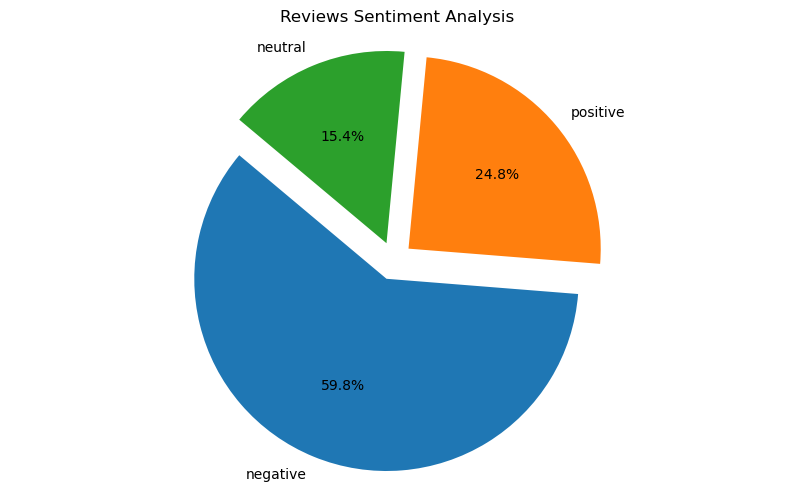

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline


plt.figure(figsize=(10, 6)) 
sen_counts = df["Sentiment"].value_counts()
num_slices = len(sen_counts)
dynamic_explode = [0.1] * num_slices 

plt.title("Reviews Sentiment Analysis")
plt.pie(
    sen_counts.values, 
    labels = sen_counts.index, 
    explode = dynamic_explode, 
    autopct = '%1.1f%%', 
    shadow = False,
    startangle = 140
)

plt.axis('equal') 
plt.show()

## Popular word and topic discovery

In [21]:
from collections import Counter

def get_most_common_nouns(dataframe, top_n=15):
    all_lemmatized_nouns = []
    
    # Using zip for speed and memory efficiency
    for lemmas, pos_list in zip(dataframe['Lemma'], dataframe['POS Tag']):
        lemma_words = str(lemmas).split()
        
        if len(lemma_words) == len(pos_list):
            for i in range(len(pos_list)):
                _, pos = pos_list[i]
                if pos == "NOUN":
                    all_lemmatized_nouns.append(lemma_words[i])
    
    counts = Counter(all_lemmatized_nouns)
    return counts.most_common(top_n)


In [22]:
# Try LDA to discorver the popular topic_counts
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
import pandas as pd

def lda_topics(dataframe, num_topics=5, words_per_topic=10):
    # Vectorize the specific subset of text
    vectorizer = CountVectorizer(stop_words='english')
    lemmas = dataframe['Lemma'].astype(str)
    
    if len(lemmas) == 0:
        return "No data provided for LDA."
        
    doc_term_matrix = vectorizer.fit_transform(lemmas)
    
    # Run LDA
    lda = LDA(n_components=num_topics, random_state=42)
    lda.fit(doc_term_matrix)
    
    feature_names = vectorizer.get_feature_names_out()
    
    # Store results
    topic_results = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-(words_per_topic + 1):-1]]
        topic_results.append((topic_idx + 1, top_words))
        
    return topic_results

In [23]:
print("--- Overall Frequency Analysis ---")
print(get_most_common_nouns(df))

print("\n--- Overall LDA Analysis ---")
lda_out = lda_topics(df)
for idx, words in lda_out:
    print(f"Topic {idx}: {', '.join(words)}")

--- Overall Frequency Analysis ---
[('flight', 5565), ('seat', 2585), ('service', 1957), ('time', 1658), ('hour', 1421), ('crew', 1361), ('food', 1271), ('airline', 1219), ('cabin', 1072), ('class', 1023), ('staff', 967), ('passenger', 892), ('business', 890), ('customer', 764), ('plane', 732)]

--- Overall LDA Analysis ---
Topic 1: flight, good, crew, food, cabin, seat, ba, service, meal, time
Topic 2: british, airways, airline, ba, flight, fly, london, service, class, year
Topic 3: flight, ba, tell, customer, british, day, hour, airways, service, check
Topic 4: seat, flight, ba, class, business, economy, fly, pay, london, airline
Topic 5: flight, ba, hour, delay, service, time, london, check, heathrow, fly


In [24]:
print("--- Frequency Analysis for Negative Reviews ---")
negative_df = df[df['Sentiment'] == 'negative']
print(get_most_common_nouns(negative_df))

print("\n--- TOP COMPLAINT THEMES (LDA) ---")
lda_neg = lda_topics(negative_df, num_topics=3)
for idx, words in lda_neg:
    print(f"Negative Theme {idx}: {', '.join(words)}")

--- Frequency Analysis for Negative Reviews ---
[('flight', 3178), ('seat', 1434), ('service', 1138), ('hour', 988), ('airline', 857), ('time', 820), ('food', 692), ('class', 641), ('staff', 605), ('crew', 586), ('customer', 581), ('passenger', 559), ('business', 557), ('cabin', 529), ('day', 486)]

--- TOP COMPLAINT THEMES (LDA) ---
Negative Theme 1: flight, seat, ba, service, class, staff, business, british, airline, airways
Negative Theme 2: ba, seat, flight, food, service, class, crew, meal, cabin, airline
Negative Theme 3: flight, ba, hour, customer, tell, service, london, british, day, airways


## Wordcloud

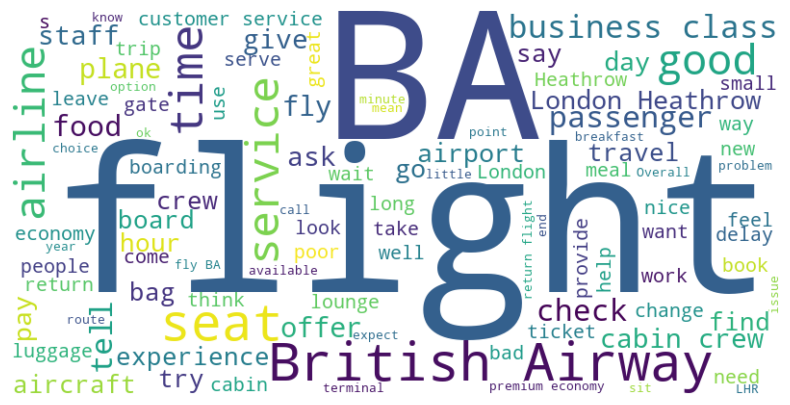

In [19]:
from wordcloud import WordCloud

# 1. Combine all lemmatized reviews into one string
all_words = " ".join(df['Lemma'].astype(str))

# 2. Generate the word cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis', 
    max_words=100
).generate(all_words)

# 3. Display the image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()